In [203]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [204]:
# Cell 2: Load dataset
df = pd.read_csv('D:/RealEstateProject/app/india_housing_prices.csv')
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [205]:
# Cell 3: Basic info
print("Shape:", df.shape)


Shape: (250000, 23)


In [206]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [207]:
df.describe()


,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [208]:
# Check missing values
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [209]:
# Fill numerical columns with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [210]:
# Cell 4: Remove Duplicates
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (250000, 23)


<!-- Step 2: Exploratory Data Analysis (EDA) -->

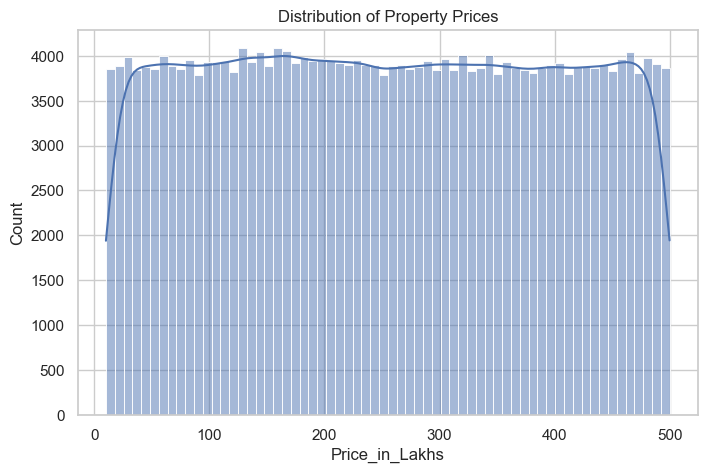

['ID',
 'State',
 'City',
 'Locality',
 'Property_Type',
 'BHK',
 'Size_in_SqFt',
 'Price_in_Lakhs',
 'Price_per_SqFt',
 'Year_Built',
 'Furnished_Status',
 'Floor_No',
 'Total_Floors',
 'Age_of_Property',
 'Nearby_Schools',
 'Nearby_Hospitals',
 'Public_Transport_Accessibility',
 'Parking_Space',
 'Security',
 'Amenities',
 'Facing',
 'Owner_Type',
 'Availability_Status']

In [211]:

# 1. Price distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Price_in_Lakhs'], kde=True)
plt.title("Distribution of Property Prices")
plt.show()
# Insight: Check skewness (right skew expected)
df.columns.tolist()

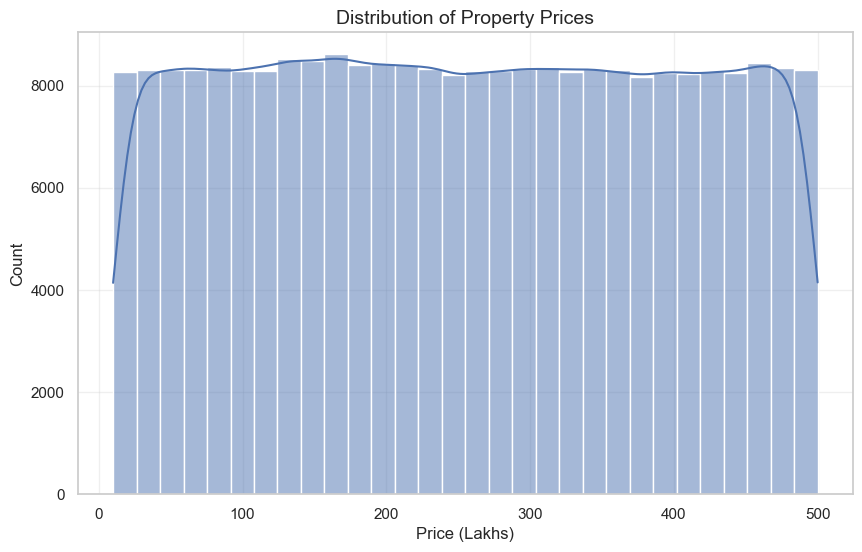

In [212]:
plt.figure(figsize=(10,6))
sns.histplot(df['Price_in_Lakhs'], kde=True, bins=30)

plt.title("Distribution of Property Prices", fontsize=14)
plt.xlabel("Price (Lakhs)")
plt.ylabel("Count")

plt.grid(alpha=0.3)
plt.show()

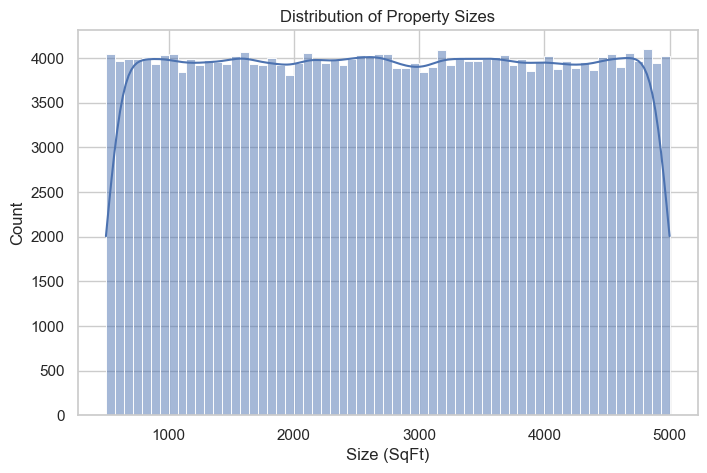

In [213]:
plt.figure(figsize=(8,5))
sns.histplot(df['Size_in_SqFt'], kde=True)

plt.title("Distribution of Property Sizes")
plt.xlabel("Size (SqFt)")
plt.ylabel("Count")

plt.show()

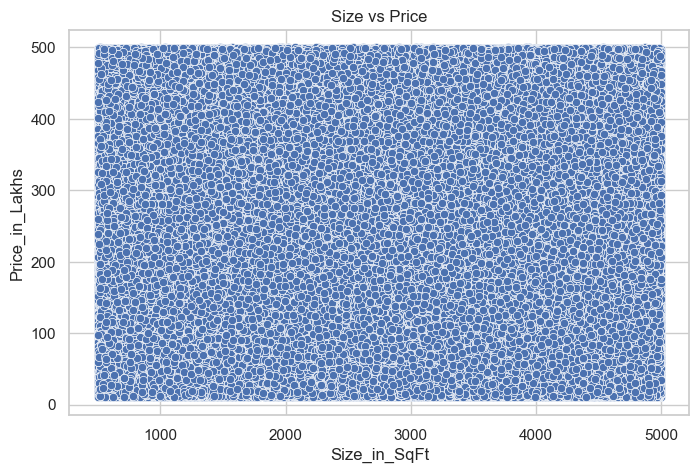

In [214]:
# 3. Price vs Size Relationship
plt.figure(figsize=(8,5))
sns.scatterplot(x='Size_in_SqFt', y='Price_in_Lakhs', data=df)
plt.title("Size vs Price")
plt.show()
# Insight: Larger size → higher price (linear trend)

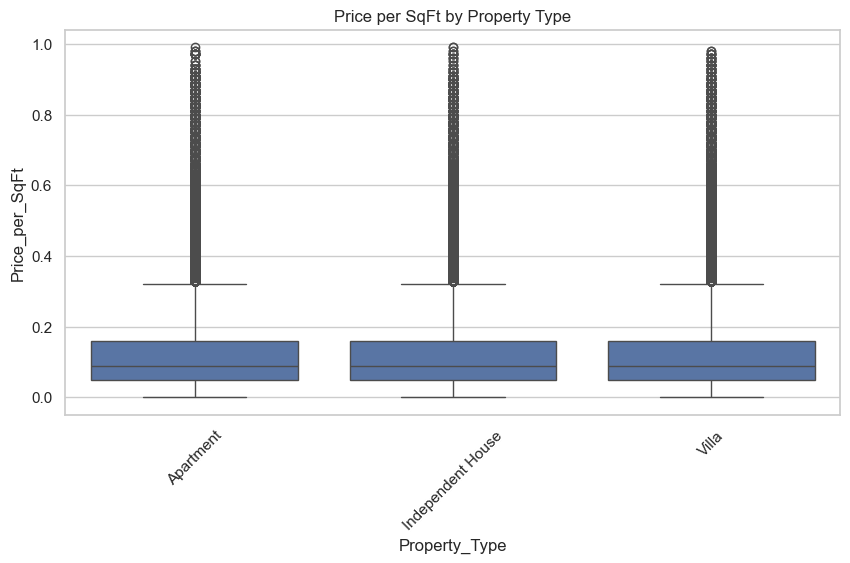

In [215]:
# 4. Price per SqFt by Property Type
plt.figure(figsize=(10,5))
sns.boxplot(x='Property_Type', y='Price_per_SqFt', data=df)
plt.xticks(rotation=45)
plt.title("Price per SqFt by Property Type")
plt.show()

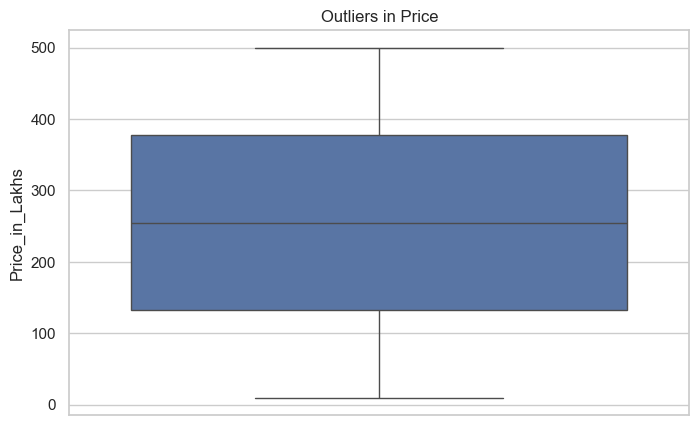

In [216]:
# 5. Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(df['Price_in_Lakhs'])
plt.title("Outliers in Price")
plt.show()

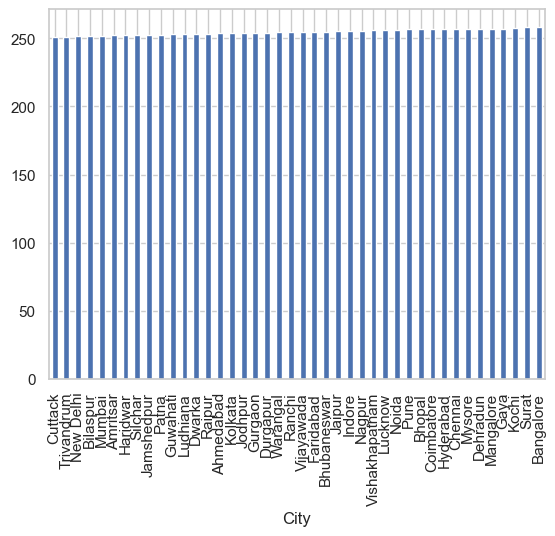

In [217]:
# 6. City-wise price
df.groupby('City')['Price_in_Lakhs'].mean().sort_values().plot(kind='bar')
plt.show()

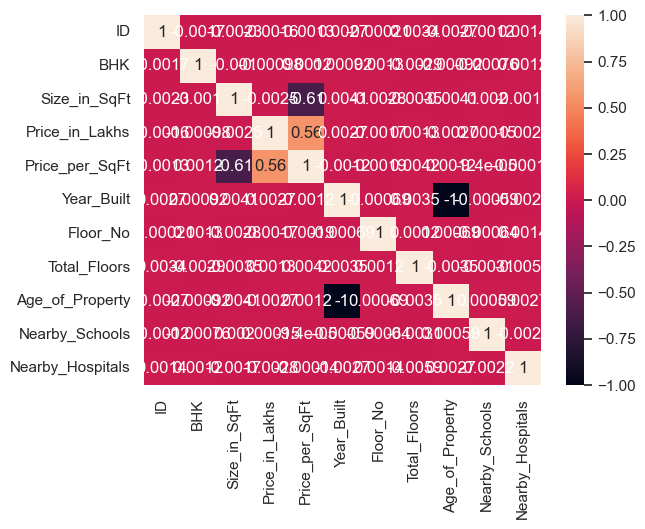

In [218]:
# 7. Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

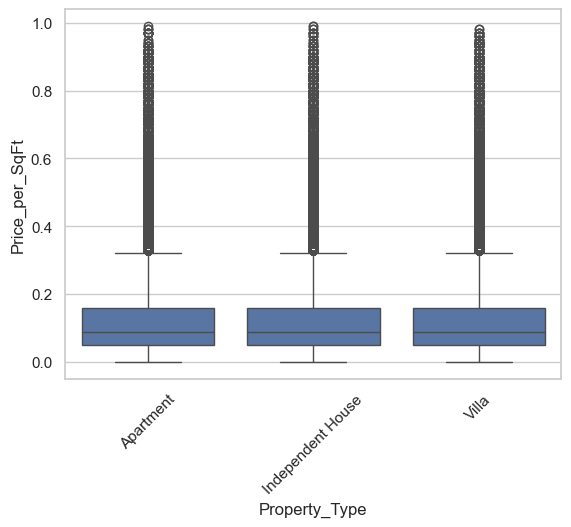

In [219]:
# 8. Property Type vs Price per SqFt
sns.boxplot(x='Property_Type', y='Price_per_SqFt', data=df)
plt.xticks(rotation=45)
plt.show()

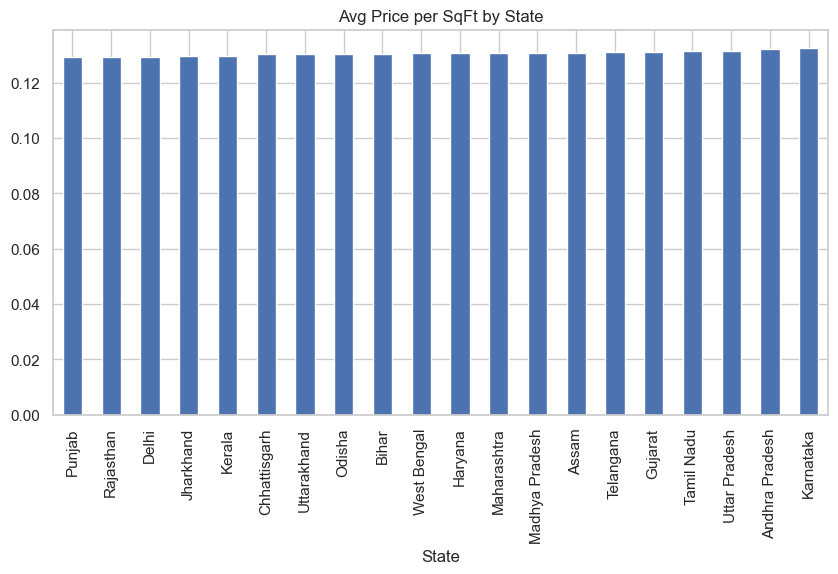

In [220]:
# LOCATION ANALYSIS
# 9. Avg Price per SqFt by State
state_avg = df.groupby('State')['Price_per_SqFt'].mean().sort_values()

state_avg.plot(kind='bar', figsize=(10,5))
plt.title("Avg Price per SqFt by State")
plt.show()

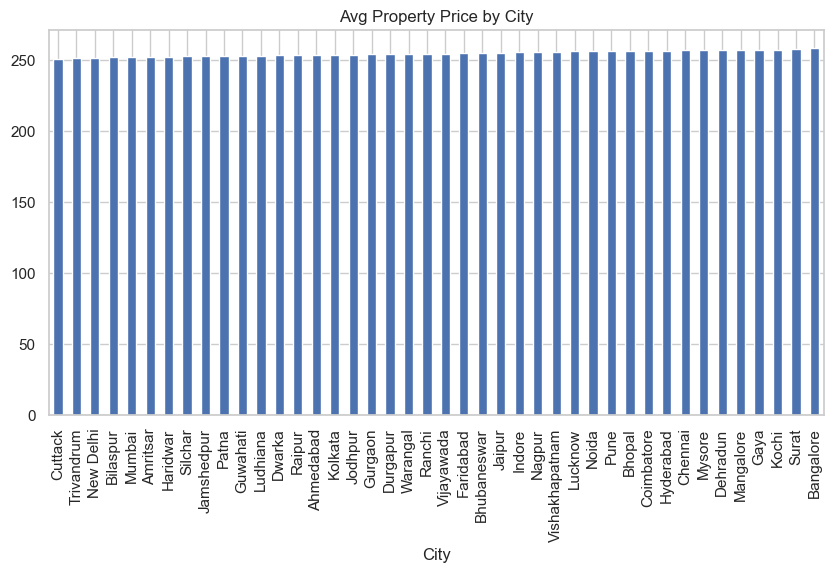

In [221]:
# 10. Avg Price by City
city_avg = df.groupby('City')['Price_in_Lakhs'].mean().sort_values()

city_avg.plot(kind='bar', figsize=(10,5))
plt.title("Avg Property Price by City")
plt.show()

In [222]:
# 11. Median Age by Locality
df['Age_of_Property'] = 2026 - df['Year_Built']

locality_age = df.groupby('Locality')['Age_of_Property'].median()

locality_age.head()

Locality
Locality_1      21.0
Locality_10     18.0
Locality_100    20.0
Locality_101    20.0
Locality_102    20.0
Name: Age_of_Property, dtype: float64

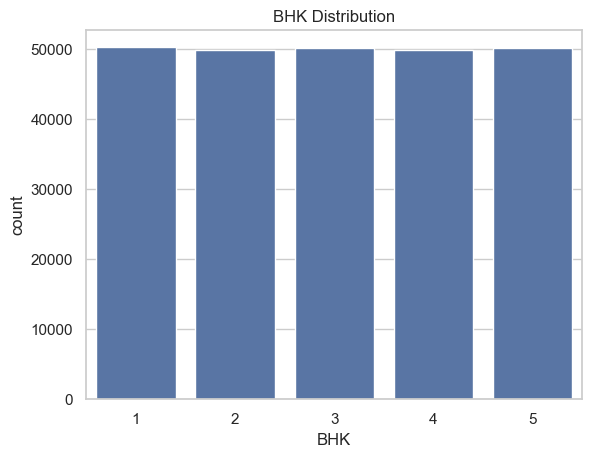

In [223]:
# 12. BHK Distribution
sns.countplot(x='BHK', data=df)
plt.title("BHK Distribution")
plt.show()

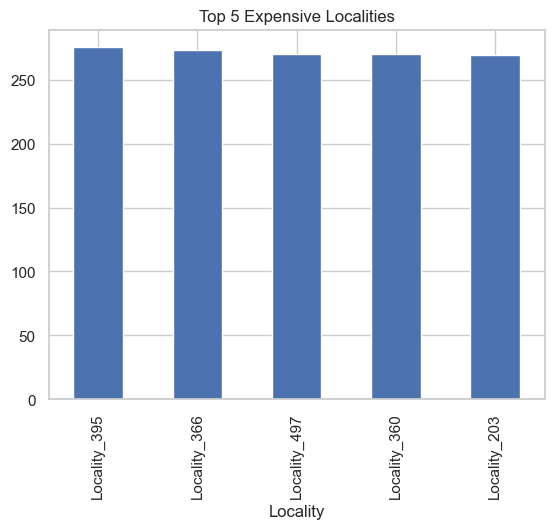

In [224]:
# 13. Top Expensive Localities
top_localities = df.groupby('Locality')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(5)

top_localities.plot(kind='bar')
plt.title("Top 5 Expensive Localities")
plt.show()

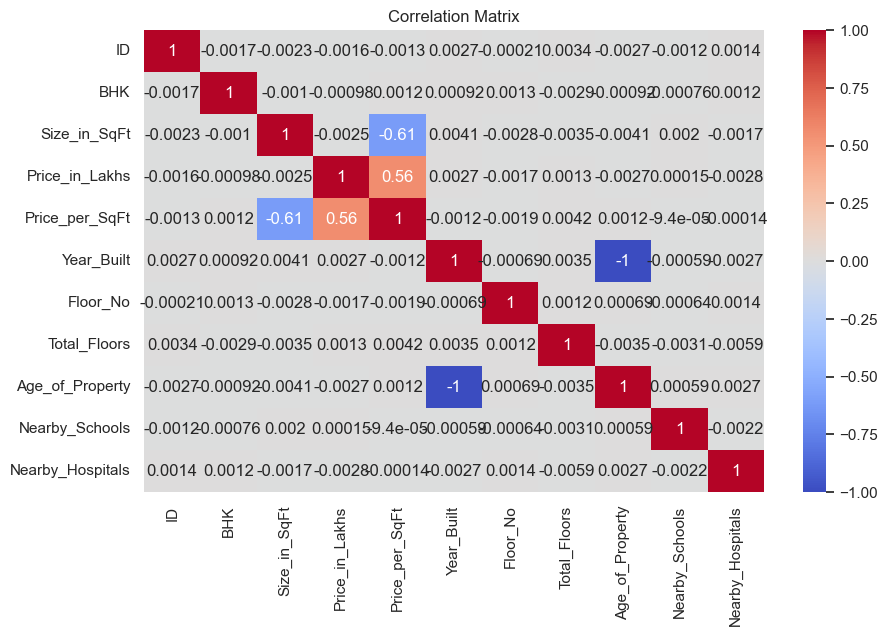

In [225]:
# FEATURE RELATIONSHIPS
# 14. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

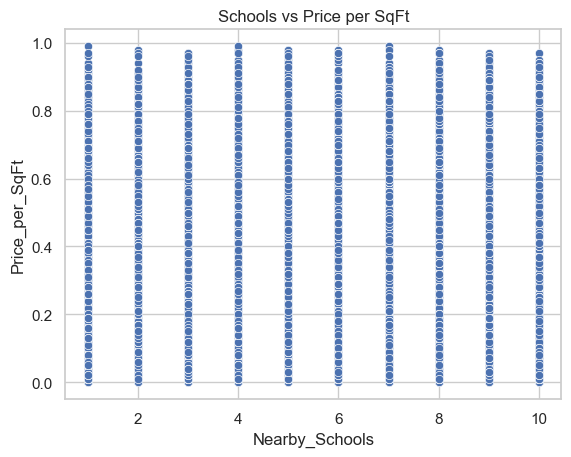

In [226]:
# 15. Schools vs Price
sns.scatterplot(x='Nearby_Schools', y='Price_per_SqFt', data=df)
plt.title("Schools vs Price per SqFt")
plt.show()


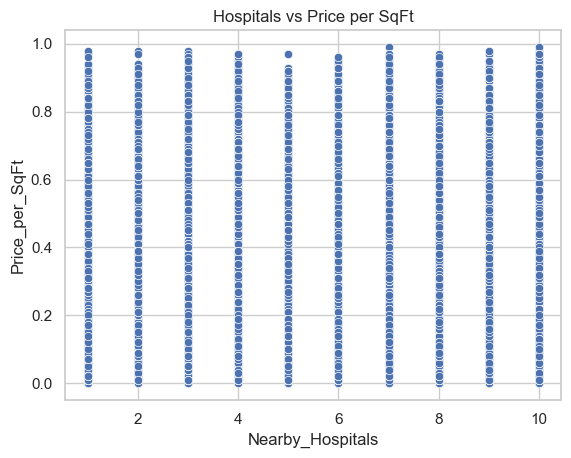

In [227]:
# 16. Hospitals vs Price
sns.scatterplot(x='Nearby_Hospitals', y='Price_per_SqFt', data=df)
plt.title("Hospitals vs Price per SqFt")
plt.show()

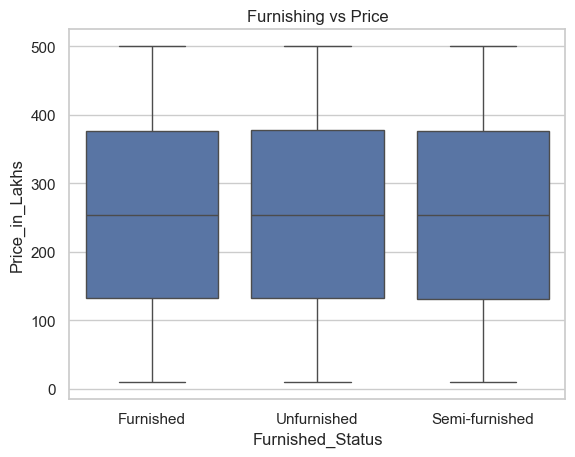

In [228]:
# 17. Furnishing vs Price
sns.boxplot(x='Furnished_Status', y='Price_in_Lakhs', data=df)
plt.title("Furnishing vs Price")
plt.show()

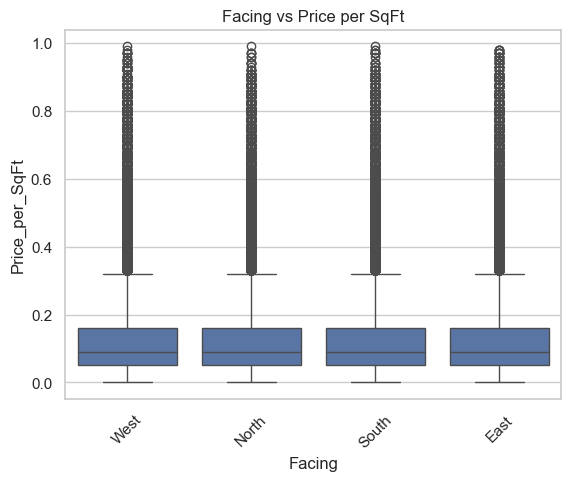

In [229]:
# 18. Facing vs Price
sns.boxplot(x='Facing', y='Price_per_SqFt', data=df)
plt.xticks(rotation=45)
plt.title("Facing vs Price per SqFt")
plt.show()

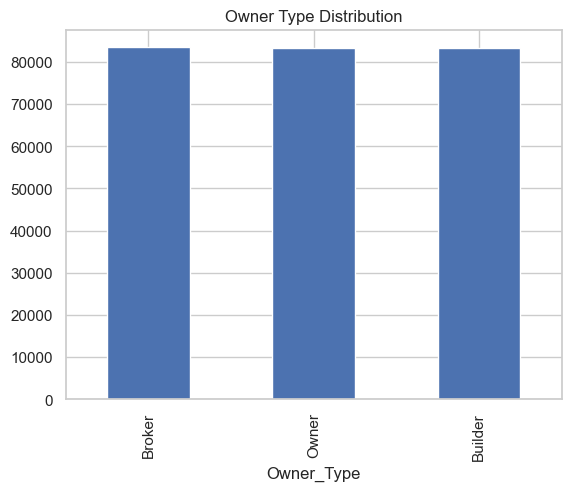

In [230]:
# INVESTMENT & AMENITIES
# 19. Owner Type Count
df['Owner_Type'].value_counts().plot(kind='bar')
plt.title("Owner Type Distribution")
plt.show()

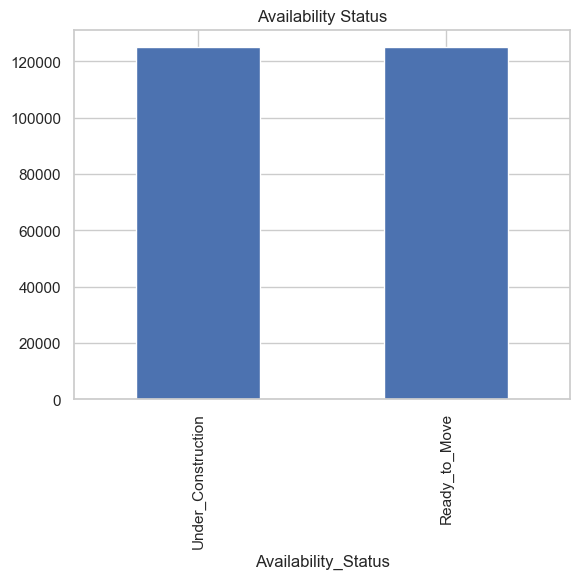

In [231]:
# 20. Availability Status
df['Availability_Status'].value_counts().plot(kind='bar')
plt.title("Availability Status")
plt.show()

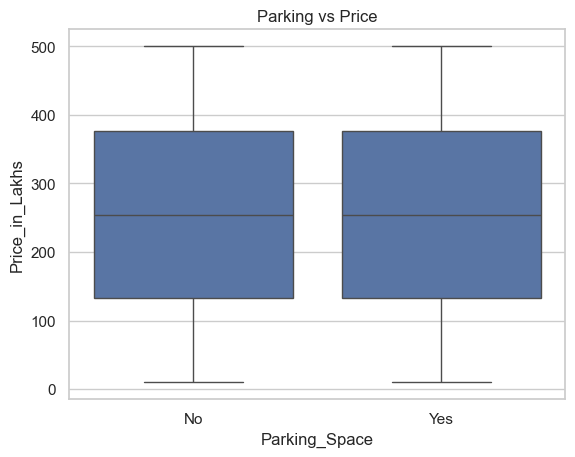

In [232]:
# 21. Parking vs Price
sns.boxplot(x='Parking_Space', y='Price_in_Lakhs', data=df)
plt.title("Parking vs Price")
plt.show()

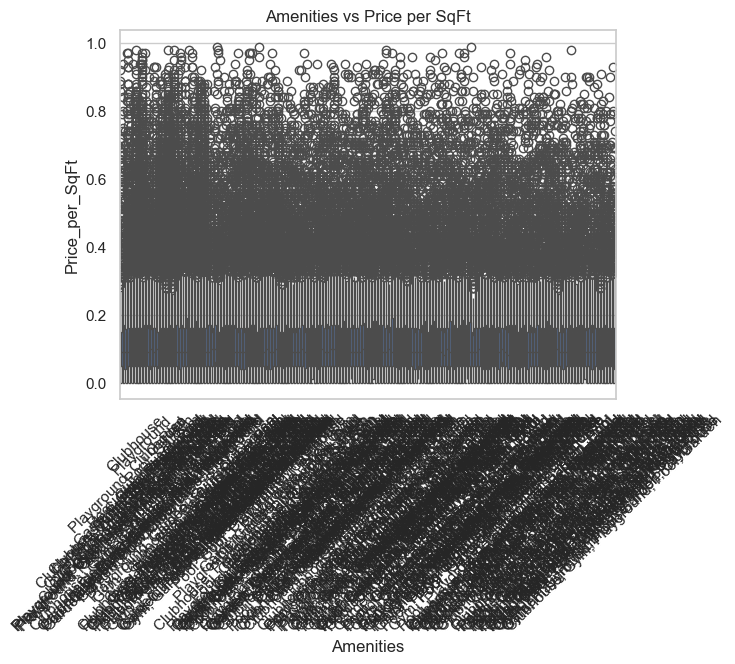

In [233]:
# 22. Amenities Impact
sns.boxplot(x='Amenities', y='Price_per_SqFt', data=df)
plt.xticks(rotation=45)
plt.title("Amenities vs Price per SqFt")
plt.show()


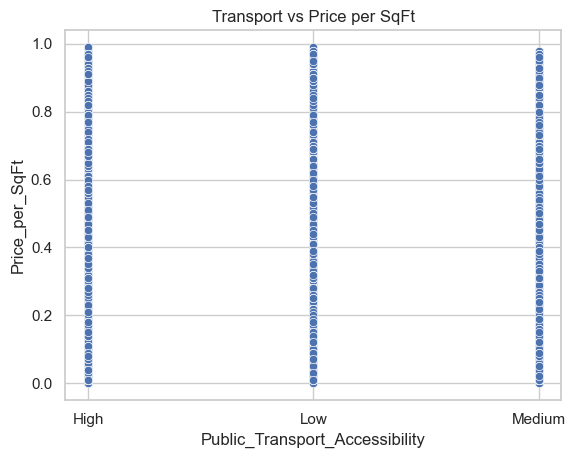

In [234]:
# 23
# . Transport vs Price
sns.scatterplot(x='Public_Transport_Accessibility', y='Price_per_SqFt', data=df)
plt.title("Transport vs Price per SqFt")
plt.show()

In [235]:
# 24. printing 
print(" Key Insights:")
print("- Property prices are positively correlated with size.")
print("- Metro cities have higher price per sqft.")
print("- Amenities and transport access increase property value.")
print("- Furnished properties are generally more expensive.")
print("- Lower price than median can indicate good investment.")

 Key Insights:
- Property prices are positively correlated with size.
- Metro cities have higher price per sqft.
- Amenities and transport access increase property value.
- Furnished properties are generally more expensive.
- Lower price than median can indicate good investment.


In [236]:
# STEP 4: Feature Engineering
# Price per SqFt 
df['Price_per_SqFt'] = (df['Price_in_Lakhs'] * 100000) / df['Size_in_SqFt']

In [237]:
# Age of Property
df['Age_of_Property'] = 2026 - df['Year_Built']

In [238]:
# Total Amenities Score
df['Amenities_Count'] = df['Amenities'].apply(lambda x: len(str(x).split(',')))

In [239]:
# Location Score
df['Public_Transport_Accessibility'].unique()
df['Public_Transport_Accessibility'] = df['Public_Transport_Accessibility'].map({
    'Low': 1,
    'Medium': 2,
    'High': 3
}).fillna(0)
df['Location_Score'] = (
    df['Nearby_Schools'] +
    df['Nearby_Hospitals'] +
    df['Public_Transport_Accessibility']
)

In [240]:
# 2. Target Variable Create
df['Good_Investment'] = (
    (df['Price_per_SqFt'] < df['Price_per_SqFt'].median()) &
    (df['Amenities_Count'] >= 2) &
    (df['BHK'] >= 2)
).astype(int)

In [241]:
print(df.columns.tolist())
df.to_csv('../data/cleaned_data.csv', index=False)
print("Cleaned dataset saved!")

['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status', 'Amenities_Count', 'Location_Score', 'Good_Investment']
Cleaned dataset saved!


In [242]:
# =========================
# STEP 4: Feature Engineering (FINAL)
# =========================

import pandas as pd

# 1. Ensure numeric columns
num_cols = [
    'bhk', 'size_in_sqft', 'price_in_lakhs', 'price_per_sqft',
    'year_built', 'floor_no', 'total_floors', 'age_of_property',
    'nearby_schools', 'nearby_hospitals',
    'public_transport_accessibility',
    'parking_space', 'amenities_count', 'location_score'
]

for col in num_cols:
    if col in df.columns:   
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Handle missing values
df.fillna(0, inplace=True)

# 3. Drop unnecessary columns (if still present)
cols_to_drop = ['state']  # already less useful for ML

df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

# 4. Define Features & Targets

# 🎯 Features
X = df.drop(['Price_in_Lakhs', 'Good_Investment'], axis=1)

# 🎯 Targets
y_class = df['Good_Investment']   # Classification
y_reg = df['Price_in_Lakhs']      # Regression

# 5. Final check
print("Feature shape:", X.shape)
print("Classification target:", y_class.shape)
print("Regression target:", y_reg.shape)

Feature shape: (250000, 24)
Classification target: (250000,)
Regression target: (250000,)


In [243]:
# Create Target Variable (Good Investment)
# Median price
median_price = df['Price_in_Lakhs'].median()

df['Good_Investment'] = df['Price_in_Lakhs'].apply(
    lambda x: 1 if x <= median_price else 0
)

In [244]:
# “Categorical features were already encoded, so we focused on 
# data cleaning, feature validation, and preparing model-ready 
# inputs.”